# Level 1 - Task 1: Data Exploration and Preprocessing

### Objective

Explore and preprocess the Zomato restaurant dataset by:

- Identifying the number of rows and columns.
- Checking for missing values in each column.
- Handling missing values appropriately.
- Checking and converting data types where necessary.
- Analyzing the distribution of the target variable, `Aggregate rating`.
- Identifying potential class imbalance in the target variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 # Load Dataset

In [2]:
df = pd.read_csv("../Dataset/zomato.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# Number of Rows and Columns

In [3]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 9551
Number of columns: 21


# Column Names

In [4]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Restaurant ID
2. Restaurant Name
3. Country Code
4. City
5. Address
6. Locality
7. Locality Verbose
8. Longitude
9. Latitude
10. Cuisines
11. Average Cost for two
12. Currency
13. Has Table booking
14. Has Online delivery
15. Is delivering now
16. Switch to order menu
17. Price range
18. Aggregate rating
19. Rating color
20. Rating text
21. Votes


# Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

# Missing Values

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


# Missing Value Percentage

In [10]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print(missing_summary)

                      Missing Values  Missing Percentage
Address                            0            0.000000
Aggregate rating                   0            0.000000
Average Cost for two               0            0.000000
City                               0            0.000000
Country Code                       0            0.000000
Cuisines                           9            0.094231
Currency                           0            0.000000
Has Online delivery                0            0.000000
Has Table booking                  0            0.000000
Is delivering now                  0            0.000000
Latitude                           0            0.000000
Locality                           0            0.000000
Locality Verbose                   0            0.000000
Longitude                          0            0.000000
Price range                        0            0.000000
Rating color                       0            0.000000
Rating text                    

# Visualize Missing Values

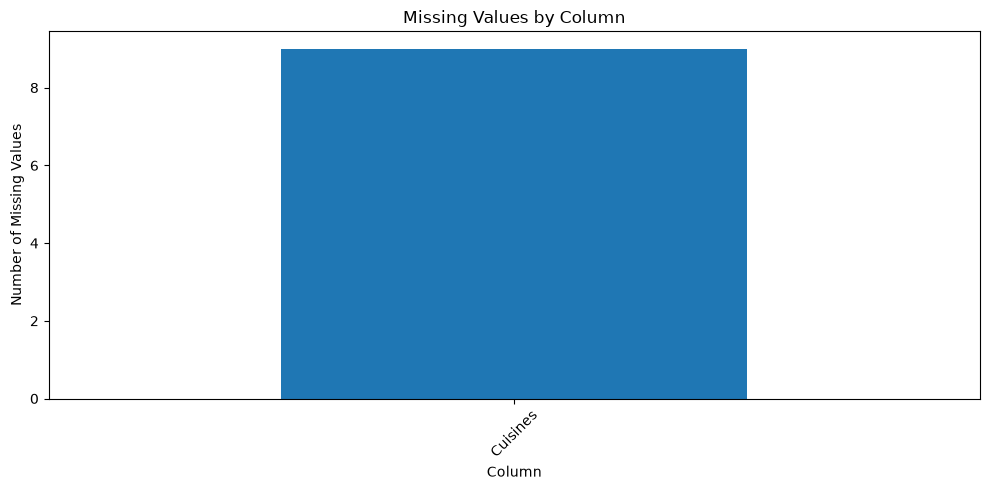

In [11]:
missing_columns = missing_summary[
    missing_summary["Missing Values"] > 0
]

if len(missing_columns) > 0:
    plt.figure(figsize=(10, 5))

    missing_columns["Missing Values"].plot(kind="bar")

    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# Handle Missing Values

In [12]:
print("Columns containing missing values:")

print(
    df.columns[df.isnull().any()].tolist()
)

Columns containing missing values:
['Cuisines']


In [13]:
if "Cuisines" in df.columns and df["Cuisines"].isnull().sum() > 0:
    df["Cuisines"] = df["Cuisines"].fillna(
        df["Cuisines"].mode()[0]
    )

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


# Verify Missing Values Were Handled

In [14]:
remaining_missing = df.isnull().sum()

print("Total missing values remaining:",
      remaining_missing.sum())

if remaining_missing.sum() == 0:
    print("All missing values have been handled successfully.")
else:
    print("Some missing values still remain:")
    print(remaining_missing[remaining_missing > 0])

Total missing values remaining: 0
All missing values have been handled successfully.


# Duplicate Rows

In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


# Data Types

In [17]:
print("Data types before conversion:\n")
print(df.dtypes)

Data types before conversion:

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object


 # Data Type Conversion

In [18]:
numeric_columns = [
    "Country Code",
    "Latitude",
    "Longitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("Data types after conversion:\n")
print(df.dtypes)

Data types after conversion:

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object


# Verify Data Types

In [19]:
print("Numerical columns:")

print(
    df.select_dtypes(include=np.number).columns.tolist()
)

print("\nCategorical columns:")

print(
    df.select_dtypes(include="object").columns.tolist()
)

Numerical columns:
['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']

Categorical columns:
['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Rating color', 'Rating text']


C:\Users\GANAVI V C\AppData\Local\Temp\ipykernel_11728\3219097920.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


### Data Type Conversion Result

The dataset was inspected for inappropriate data types. Numerical variables
such as Latitude, Longitude, Average Cost for two, Price range, Aggregate
rating, and Votes were converted to numeric types where necessary.

Categorical variables such as Restaurant Name, City, Cuisines, and service
availability fields remain as object/string types because they represent
categorical information.

# Target Variable

In [20]:
target = "Aggregate rating"

print("Target variable:", target)
print("Data type:", df[target].dtype)
print("Number of unique ratings:", df[target].nunique())

Target variable: Aggregate rating
Data type: float64
Number of unique ratings: 33


# Aggregate Rating Distribution

In [21]:
rating_distribution = (
    df["Aggregate rating"]
    .value_counts()
    .sort_index()
)

print("Aggregate Rating Distribution:")
print(rating_distribution)

Aggregate Rating Distribution:
Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


# Rating Percentages

In [22]:
rating_percentage = (
    df["Aggregate rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Aggregate Rating Percentage Distribution:")
print(rating_percentage.round(2))

Aggregate Rating Percentage Distribution:
Aggregate rating
0.0    22.49
1.8     0.01
1.9     0.02
2.0     0.07
2.1     0.16
2.2     0.28
2.3     0.49
2.4     0.91
2.5     1.15
2.6     2.00
2.7     2.62
2.8     3.30
2.9     3.99
3.0     4.90
3.1     5.43
3.2     5.47
3.3     5.06
3.4     5.21
3.5     5.03
3.6     4.80
3.7     4.47
3.8     4.19
3.9     3.51
4.0     2.79
4.1     2.87
4.2     2.31
4.3     1.82
4.4     1.51
4.5     0.99
4.6     0.82
4.7     0.44
4.8     0.26
4.9     0.64
Name: proportion, dtype: float64


# Rating Distribution Chart

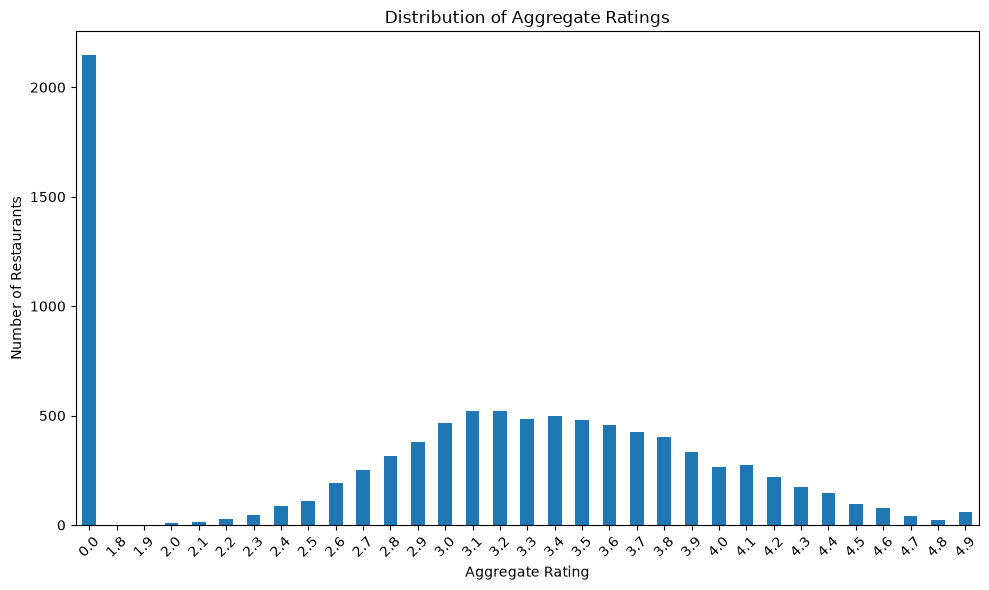

In [23]:
plt.figure(figsize=(10, 6))

rating_distribution.plot(kind="bar")

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Class Imbalance Analysis

In [24]:
most_common_rating = rating_distribution.idxmax()
most_common_count = rating_distribution.max()

least_common_rating = rating_distribution.idxmin()
least_common_count = rating_distribution.min()

most_common_percentage = (
    rating_percentage.loc[most_common_rating]
)

least_common_percentage = (
    rating_percentage.loc[least_common_rating]
)

print("Most common rating:", most_common_rating)
print("Number of restaurants:", most_common_count)
print("Percentage:", round(most_common_percentage, 2), "%")

print("\nLeast common rating:", least_common_rating)
print("Number of restaurants:", least_common_count)
print("Percentage:", round(least_common_percentage, 2), "%")

Most common rating: 0.0
Number of restaurants: 2148
Percentage: 22.49 %

Least common rating: 1.8
Number of restaurants: 1
Percentage: 0.01 %


# Identify Imbalance Using a Ratio

In [25]:
imbalance_ratio = (
    most_common_count / least_common_count
    if least_common_count > 0
    else np.inf
)

print(
    "Most-common to least-common class ratio:",
    round(imbalance_ratio, 2)
)

Most-common to least-common class ratio: 2148.0


# Class Imbalance Visualization

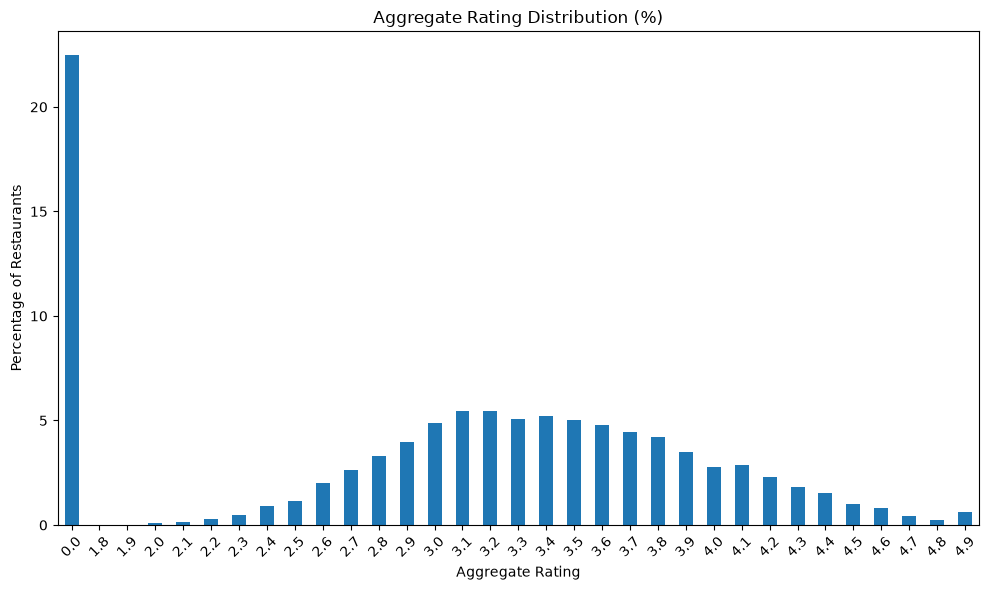

In [26]:
plt.figure(figsize=(10, 6))

rating_percentage.plot(kind="bar")

plt.title("Aggregate Rating Distribution (%)")
plt.xlabel("Aggregate Rating")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Automatically Generate the Interpretation

In [27]:
print("Class Imbalance Analysis")
print("-" * 40)

if imbalance_ratio >= 2:
    print(
        "The Aggregate rating variable shows noticeable class imbalance."
    )
    print(
        f"The most common rating ({most_common_rating}) occurs "
        f"{imbalance_ratio:.2f} times as often as the least common rating "
        f"({least_common_rating})."
    )
else:
    print(
        "The Aggregate rating distribution does not show a strong "
        "class imbalance based on the most-common to least-common "
        "class ratio."
    )

Class Imbalance Analysis
----------------------------------------
The Aggregate rating variable shows noticeable class imbalance.
The most common rating (0.0) occurs 2148.00 times as often as the least common rating (1.8).


# Final Dataset

In [28]:
print("Final dataset shape:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

print("\nFinal data types:")
print(df.dtypes)

Final dataset shape: (9551, 21)

Remaining missing values:
0

Final data types:
Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object


# Save Cleaned Dataset

In [29]:
output_path = "../Outputs/zomato_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully:")
print(output_path)

Cleaned dataset saved successfully:
../Outputs/zomato_cleaned.csv


# Key Findings

- The dataset contains 9,551 rows and 21 columns.
- Missing values were identified for each column and handled appropriately.
- The `Cuisines` missing values were filled using the mode.
- Numerical columns were checked and converted to appropriate numeric data
  types where necessary.
- `Aggregate rating` was selected as the target variable for analysis.
- The distribution of Aggregate rating was analyzed using counts,
  percentages, and visualizations.
- The most and least frequent rating categories were identified.
- The class imbalance was evaluated using the distribution and the
  most-common-to-least-common class ratio.
- The cleaned dataset was saved as `zomato_cleaned.csv`.

# Conclusion

The Zomato dataset was successfully explored and preprocessed.

The dataset contains 9,551 restaurant records and 21 columns. Missing values
were examined for every column and handled appropriately. Data types were
also inspected and numerical variables were converted where necessary.

The `Aggregate rating` target variable was analyzed using frequency counts,
percentages, and visualizations. The distribution of ratings was examined to
identify whether some rating categories occur substantially more frequently
than others.

This preprocessing provides a clean and structured dataset that can be used
for the remaining data analysis and machine learning tasks in the Cognifyz
Data Science internship.